In [1]:
%pip install grad-cam opencv-python

  Using cached grad-cam-1.5.5.tar.gz (7.8 MB)
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Using cached ttach-0.0.3-py3-none-any.whl.metadata (5.2 kB)
Using cached ttach-0.0.3-py3-none-any.whl (9.8 kB)
  Created wheel for grad-cam: filename=grad_cam-1.5.5-py3-none-any.whl size=44340 sha256=ae1a6a3263b9c7f69e3f0b0dcd7c6669356da52cc1315eaf730abcc2533099c5
  Stored in directory: c:\users\srbuh\appdata\local\pip\cache\wheels\b9\1c\2d\281a1509651a08cada4dd95a63ee095f00f234b6a96d61c089
Successfully built grad-cam

   -------------------- ------------------- 1/2 [grad-cam]
   ---------------------------------------- 2/2 [grad-cam]

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: C:\Users\srbuh\AppData\Local\Programs\Python\Python313\python.exe -m pip install --upgrade pip


In [2]:
import torch
import cv2
import numpy as np
import matplotlib.pyplot as plt
from torchvision import models, transforms
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image
from PIL import Image

# Քո dataset.py-ից (եթե path-ը խնդիր տա, ուղղակի այս մասը ձեռքով կգրենք)
import sys
sys.path.append('../src')
from dataset import ChestXrayDataset

print("Libraries imported!")

Libraries imported!


In [3]:
# 1. Սարքում ենք Մոդելի կմախքը
device = "cuda" if torch.cuda.is_available() else "cpu"
model = models.resnet50(pretrained=False)
model.fc = torch.nn.Linear(model.fc.in_features, 14)

# 2. Բեռնում ենք քո սովորած կշիռները
# Համոզվիր, որ այս ֆայլը գոյություն ունի
model_path = '../models/resnet50_best.pth'

try:
    model.load_state_dict(torch.load(model_path, map_location=device))
    print(f"✅ Model loaded form {model_path}")
except FileNotFoundError:
    print(f"❌ Error: Model file not found at {model_path}")

model = model.to(device)
model.eval() # Շատ կարևոր է GradCAM-ի համար

# 3. Թիրախային շերտը (ResNet-ի վերջին convolutional շերտը)
target_layers = [model.layer4[-1]]

C:\Users\srbuh\AppData\Local\Programs\Python\Python313\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\srbuh\AppData\Local\Programs\Python\Python313\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


✅ Model loaded form ../models/resnet50_best.pth


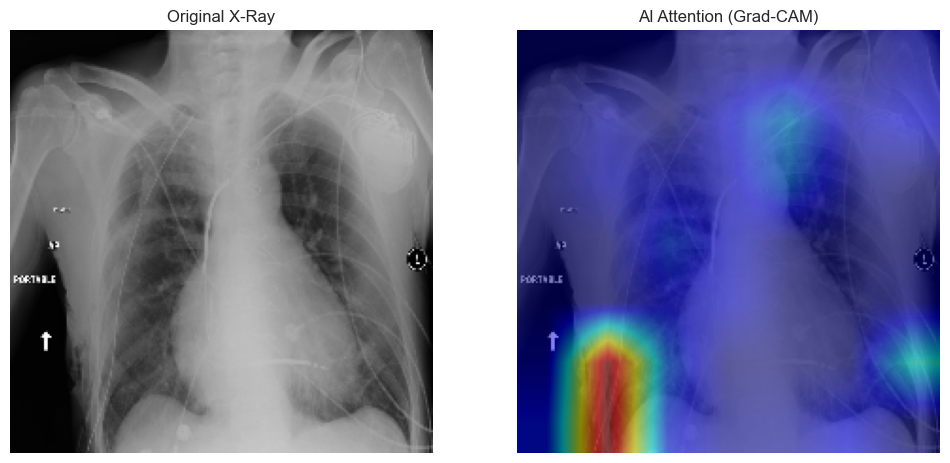

In [4]:
# Փոխիր նկարի անունը մի նկարով, որը ունի ախտաբանություն
# Օրինակ՝ 00000013_026.png (Cardiomegaly)
img_name = '00000013_026.png'
img_path = f'../data/images/{img_name}'

# Ֆունկցիա նկարը բացելու համար
def preprocess_image(path):
    img = Image.open(path).convert('RGB')
    img = np.array(img)
    img = cv2.resize(img, (224, 224))
    img = np.float32(img) / 255 # 0-1 range
    return img

# Tensor սարքելու համար
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Process
try:
    rgb_img = preprocess_image(img_path)
    input_tensor = transform(rgb_img).unsqueeze(0).to(device)

    # --- Grad-CAM ---
    cam = GradCAM(model=model, target_layers=target_layers)
    grayscale_cam = cam(input_tensor=input_tensor, targets=None)
    grayscale_cam = grayscale_cam[0, :]
    visualization = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)

    # Plot
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.imshow(rgb_img)
    plt.title("Original X-Ray")
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(visualization)
    plt.title("AI Attention (Grad-CAM)")
    plt.axis('off')
    plt.show()

except FileNotFoundError:
    print(f"❌ Image not found: {img_path}")